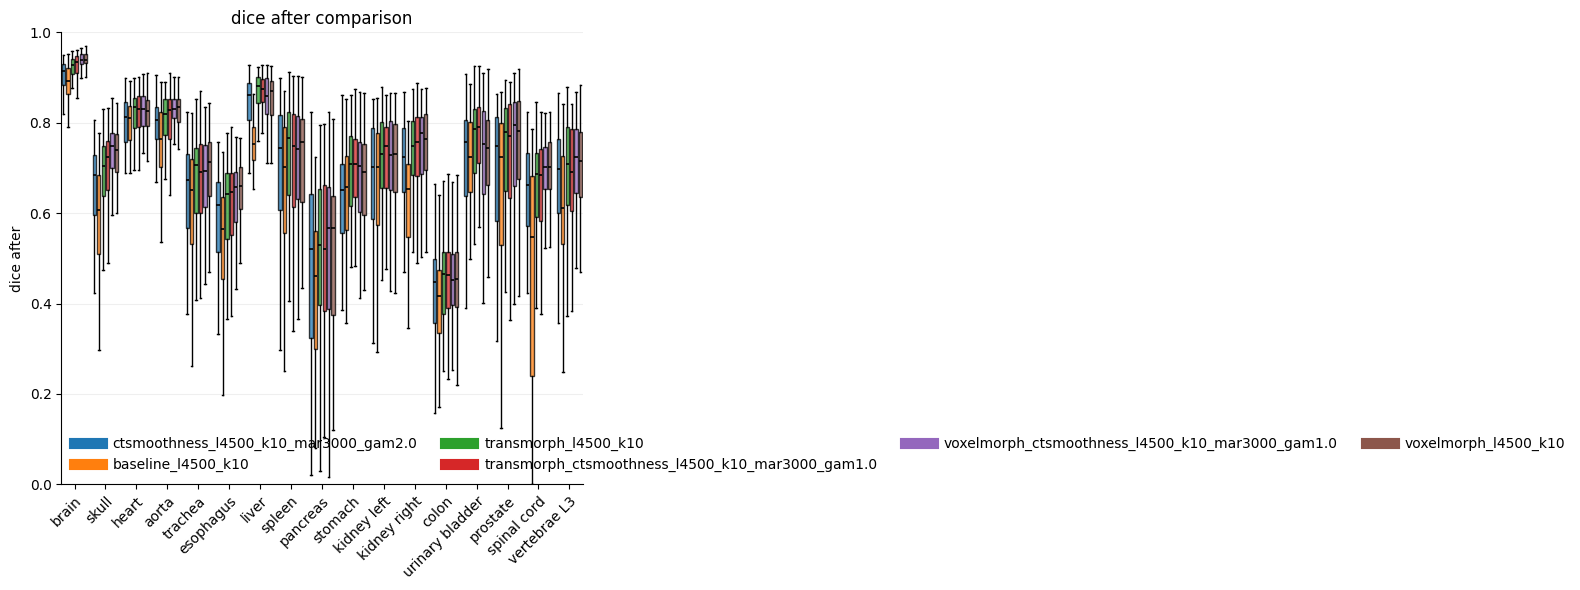

In [1]:
import ast
import os

import matplotlib.pyplot as plt
import numpy as np


DEFAULT_ORGANS = [
    "brain",
    "skull",
    "heart",
    "aorta",
    "trachea",
    "esophagus",
    "liver",
    "spleen",
    "pancreas",
    "stomach",
    "kidney_left",
    "kidney_right",
    "colon",
    "urinary_bladder",
    "prostate",
    "spinal_cord",
    "vertebrae_L3",
]

TXT_FILES = [
    "/share/home/xcwu/pet_reg_results/ctsmoothness_l4500_k10_mar3000_gam2.0.txt",
    "/share/home/xcwu/pet_reg_results/baseline_l4500_k10.txt",
    "/share/home/xcwu/pet_reg_results/transmorph_l4500_k10.txt",
    "/share/home/xcwu/pet_reg_results/transmorph_ctsmoothness_l4500_k10_mar3000_gam1.0.txt",
    # "/share/home/xcwu/pet_reg_results/svr_diff_l4500_k10_mar3000_beta1_a1.1_b1_repo_logbeta.txt",
    "/share/home/xcwu/pet_reg_results/voxelmorph_ctsmoothness_l4500_k10_mar3000_gam1.0.txt",
    "/share/home/xcwu/pet_reg_results/voxelmorph_l4500_k10.txt",
    
]

LABELS = None
METRIC = "dice_after"
ORGANS = DEFAULT_ORGANS
USE_HORIZONTAL = False
SHOW_FLIERS = False
TITLE = None
OUTPUT = None


def parse_list_line(line):
    values = []
    for part in line.strip().split(";"):
        part = part.strip()
        try:
            values.append(ast.literal_eval(part))
        except Exception:
            values.append(part)
    return values


def load_registration_results(filename):
    """
    Load one registration result txt produced by Registration/inferencing.py.

    Returns:
        dict with masks_names, dice_before, dice_after, tre_before, tre_after.
    """
    with open(filename, "r") as f:
        lines = f.readlines()

    if len(lines) < 5:
        raise ValueError(
            f"{filename} should contain at least 5 lines: masks, dice before, "
            "dice after, TRE before, TRE after."
        )

    return {
        "masks_names": parse_list_line(lines[0]),
        "dice_before": parse_list_line(lines[1]),
        "dice_after": parse_list_line(lines[2]),
        "tre_before": parse_list_line(lines[3]),
        "tre_after": parse_list_line(lines[4]),
    }


def get_metrics_for_masks(
    mask_names_input,
    masks_names,
    dice_before_lists,
    dice_after_lists,
    tre_before_lists,
    tre_after_lists,
):
    results = {}
    for name in mask_names_input:
        if name in masks_names:
            idx = masks_names.index(name)
            results[name] = {
                "dice_before": dice_before_lists[idx],
                "dice_after": dice_after_lists[idx],
                "tre_before": tre_before_lists[idx],
                "tre_after": tre_after_lists[idx],
            }
        else:
            results[name] = {
                "dice_before": None,
                "dice_after": None,
                "tre_before": None,
                "tre_after": None,
            }
    return results


def default_label_from_path(path):
    return os.path.splitext(os.path.basename(path))[0]


def common_organs(results):
    common = set(results[0]["masks_names"])
    for result in results[1:]:
        common &= set(result["masks_names"])

    return [organ for organ in results[0]["masks_names"] if organ in common]


def choose_organs(results, organs, use_default_organs):
    available = common_organs(results)
    if organs:
        missing = [organ for organ in organs if organ not in available]
        if missing:
            raise ValueError(
                "These organs are missing from at least one txt file: "
                + ", ".join(missing)
            )
        return organs

    if use_default_organs:
        selected = [organ for organ in DEFAULT_ORGANS if organ in available]
        if selected:
            return selected

    return available


def collect_metric_data(results, metric, selected_organs):
    all_data = []
    for result in results:
        masks_names = result["masks_names"]
        metric_lists = result[metric]
        data_for_file = []

        for organ in selected_organs:
            organ_index = masks_names.index(organ)
            data_for_file.append(np.asarray(metric_lists[organ_index], dtype=float))

        all_data.append(data_for_file)

    return all_data


def make_colors(num_items):
    cmap = plt.get_cmap("tab10")
    return [cmap(i % 10) for i in range(num_items)]


def plot_metric_boxplot(
    results,
    labels,
    selected_organs,
    metric="dice_after",
    title=None,
    orientation="vertical",
    show_fliers=False,
):
    """
    Plot grouped boxplots. Each txt file becomes one boxplot series.
    """
    metric_data = collect_metric_data(results, metric, selected_organs)
    num_organs = len(selected_organs)
    num_files = len(results)

    if num_organs == 0:
        raise ValueError("No organs selected for plotting.")

    colors = make_colors(num_files)
    group_spacing = num_files + 1
    positions_base = np.arange(num_organs) * group_spacing
    box_width = 0.75

    if orientation == "horizontal":
        fig, ax = plt.subplots(figsize=(9, max(5, num_organs * 0.45)))
    else:
        fig, ax = plt.subplots(figsize=(max(10, num_organs * 0.7), 6))

    for file_index, (data_for_file, label) in enumerate(zip(metric_data, labels)):
        offset = file_index - (num_files - 1) / 2
        positions = positions_base + offset

        boxplot_kwargs = {
            "positions": positions,
            "widths": box_width,
            "patch_artist": True,
            "showfliers": show_fliers,
            "flierprops": {
                "marker": "o",
                "markersize": 3,
                "linestyle": "none",
                "markerfacecolor": "black",
                "alpha": 0.45,
            },
        }
        if orientation == "horizontal":
            boxplot_kwargs["vert"] = False

        bp = ax.boxplot(data_for_file, **boxplot_kwargs)
        for patch in bp["boxes"]:
            patch.set_facecolor(colors[file_index])
            patch.set_alpha(0.75)
        for median in bp["medians"]:
            median.set_color("black")
            median.set_linewidth(1.2)

        ax.plot([], [], color=colors[file_index], linewidth=8, label=label)

    clean_organs = [organ.replace("_", " ") for organ in selected_organs]
    if orientation == "horizontal":
        ax.set_yticks(positions_base)
        ax.set_yticklabels(clean_organs)
        ax.set_xlabel(metric.replace("_", " "))
        if metric.startswith("dice"):
            ax.set_xlim(0, 1)
    else:
        ax.set_xticks(positions_base)
        ax.set_xticklabels(
            clean_organs,
            rotation=45,
            ha="right",
            rotation_mode="anchor",
        )
        ax.set_ylabel(metric.replace("_", " "))
        if metric.startswith("dice"):
            ax.set_ylim(0, 1)

    if title:
        ax.set_title(title)

    ax.legend(ncol=min(num_files, 4), frameon=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="x" if orientation == "horizontal" else "y", alpha=0.2)

    fig.tight_layout()
    return fig, ax


def plot_boxplots_from_txt_files(
    txt_files,
    labels=None,
    metric="dice_after",
    organs=None,
    use_horizontal=False,
    show_fliers=False,
    title=None,
    output=None,
):
    results = [load_registration_results(path) for path in txt_files]

    if labels is None:
        labels = [default_label_from_path(path) for path in txt_files]
    if len(labels) != len(txt_files):
        raise ValueError("labels must have the same length as txt_files.")

    selected_organs = choose_organs(
        results,
        organs=organs,
        use_default_organs=False,
    )

    if title is None:
        title = f"{metric.replace('_', ' ')} comparison"

    fig, _ = plot_metric_boxplot(
        results,
        labels,
        selected_organs,
        metric=metric,
        title=title,
        orientation="horizontal" if use_horizontal else "vertical",
        show_fliers=show_fliers,
    )

    if output:
        fig.savefig(output, dpi=300, bbox_inches="tight")
        print(f"Saved figure to {output}")

    plt.show()
    return fig


def main():
    if not TXT_FILES:
        raise ValueError("Please fill TXT_FILES with one or more result txt paths.")

    plot_boxplots_from_txt_files(
        TXT_FILES,
        labels=LABELS,
        metric=METRIC,
        organs=ORGANS,
        use_horizontal=USE_HORIZONTAL,
        show_fliers=SHOW_FLIERS,
        title=TITLE,
        output=OUTPUT,
    )


if __name__ == "__main__":
    main()


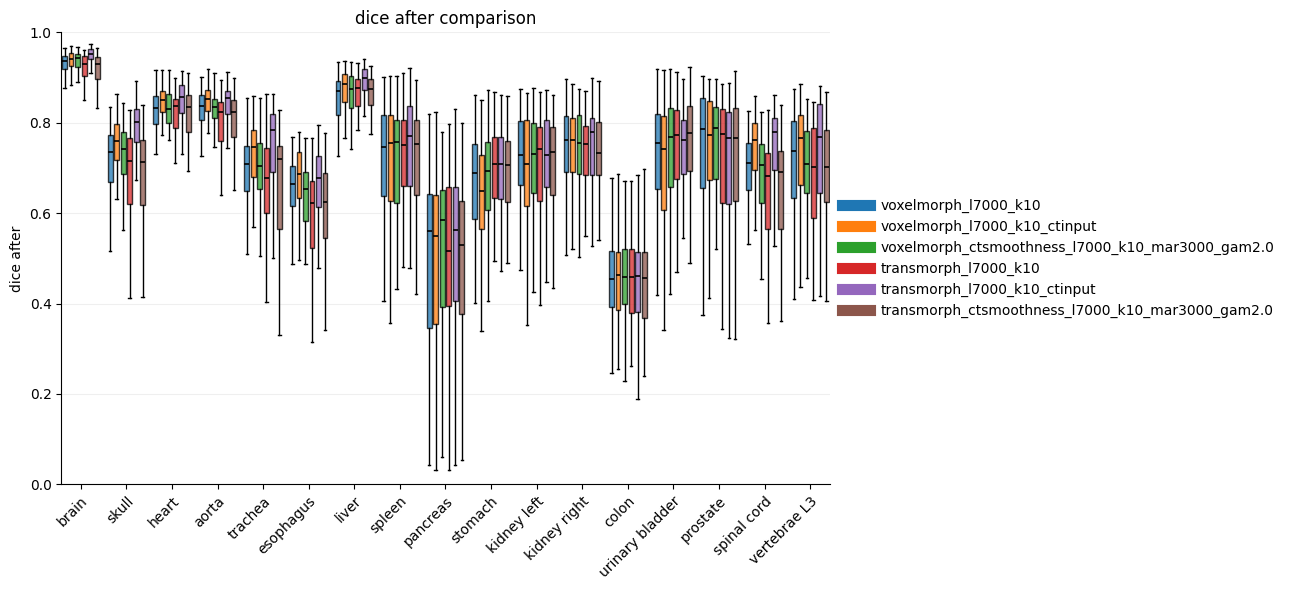

In [11]:

import ast
import os

import matplotlib.pyplot as plt
import numpy as np

DEFAULT_ORGANS = [
    "brain",
    "skull",
    "heart",
    "aorta",
    "trachea",
    "esophagus",
    "liver",
    "spleen",
    "pancreas",
    "stomach",
    "kidney_left",
    "kidney_right",
    "colon",
    "urinary_bladder",
    "prostate",
    "spinal_cord",
    "vertebrae_L3",
]

TXT_FILES = [
    # "voxelmorph_l7000_k10.txt",
    "/share/home/xcwu/pet_reg_results/voxelmorph_l7000_k10.txt",
    "/share/home/xcwu/pet_reg_results/voxelmorph_l7000_k10_ctinput.txt",
    "/share/home/xcwu/pet_reg_results/voxelmorph_ctsmoothness_l7000_k10_mar3000_gam2.0.txt",
    "/share/home/xcwu/pet_reg_results/transmorph_l7000_k10.txt",
    "/share/home/xcwu/pet_reg_results/transmorph_l7000_k10_ctinput.txt",
    "/share/home/xcwu/pet_reg_results/transmorph_ctsmoothness_l7000_k10_mar3000_gam2.0.txt",
]

LABELS = None
METRIC = "dice_after"
ORGANS = DEFAULT_ORGANS
USE_HORIZONTAL = False
SHOW_FLIERS = False
TITLE = None
OUTPUT = None

def parse_list_line(line):
    values = []
    for part in line.strip().split(";"):
        part = part.strip()
        try:
            values.append(ast.literal_eval(part))
        except Exception:
            values.append(part)
    return values

def load_registration_results(filename):
    """
    Load one registration result txt produced by Registration/inferencing.py.

    Returns:
        dict with masks_names, dice_before, dice_after, tre_before, tre_after.
    """
    with open(filename, "r") as f:
        lines = f.readlines()

    if len(lines) < 5:
        raise ValueError(
            f"{filename} should contain at least 5 lines: masks, dice before, "
            "dice after, TRE before, TRE after."
        )

    return {
        "masks_names": parse_list_line(lines[0]),
        "dice_before": parse_list_line(lines[1]),
        "dice_after": parse_list_line(lines[2]),
        "tre_before": parse_list_line(lines[3]),
        "tre_after": parse_list_line(lines[4]),
    }

def common_organs(results):
    common = set(results[0]["masks_names"])
    for result in results[1:]:
        common &= set(result["masks_names"])

    return [organ for organ in results[0]["masks_names"] if organ in common]

def choose_organs(results, organs, use_default_organs):
    available = common_organs(results)
    if organs:
        missing = [organ for organ in organs if organ not in available]
        if missing:
            raise ValueError(
                "These organs are missing from at least one txt file: "
                ", ".join(missing)
            )
        return organs

    if use_default_organs:
        selected = [organ for organ in DEFAULT_ORGANS if organ in available]
        if selected:
            return selected

    return available

def collect_metric_data(results, metric, selected_organs):
    all_data = []
    for result in results:
        masks_names = result["masks_names"]
        metric_lists = result[metric]
        data_for_file = []

        for organ in selected_organs:
            organ_index = masks_names.index(organ)
            data_for_file.append(np.asarray(metric_lists[organ_index], dtype=float))

        all_data.append(data_for_file)

    return all_data

def make_colors(num_items):
    cmap = plt.get_cmap("tab10")
    return [cmap(i % 10) for i in range(num_items)]

def plot_metric_boxplot(
    results,
    labels,
    selected_organs,
    metric="dice_after",
    title=None,
    orientation="vertical",
    show_fliers=False,
):
    """
    Plot grouped boxplots. Each txt file becomes one boxplot series.
    """
    metric_data = collect_metric_data(results, metric, selected_organs)
    num_organs = len(selected_organs)
    num_files = len(results)

    if num_organs == 0:
        raise ValueError("No organs selected for plotting.")

    colors = make_colors(num_files)
    group_spacing = num_files + 1
    positions_base = np.arange(num_organs) * group_spacing
    box_width = 0.75

    # 1. 调整画布大小，如果是垂直布局，增加宽度以容纳右侧图例
    if orientation == "horizontal":
        fig, ax = plt.subplots(figsize=(9, max(5, num_organs * 0.45)))
    else:
        # 增加宽度 (例如 12 或更多)，防止图例遮挡图形
        fig, ax = plt.subplots(figsize=(max(14, num_organs * 0.9), 6))

    for file_index, (data_for_file, label) in enumerate(zip(metric_data, labels)):
        offset = file_index - (num_files - 1) / 2
        positions = positions_base + offset

        boxplot_kwargs = {
            "positions": positions,
            "widths": box_width,
            "patch_artist": True,
            "showfliers": show_fliers,
            "flierprops": {
                "marker": "o",
                "markersize": 3,
                "linestyle": "none",
                "markerfacecolor": "black",
                "alpha": 0.45,
            },
        }
        if orientation == "horizontal":
            boxplot_kwargs["vert"] = False

        bp = ax.boxplot(data_for_file, **boxplot_kwargs)
        for patch in bp["boxes"]:
            patch.set_facecolor(colors[file_index])
            patch.set_alpha(0.75)
        for median in bp["medians"]:
            median.set_color("black")
            median.set_linewidth(1.2)

        # 用于图例的空线条
        ax.plot([], [], color=colors[file_index], linewidth=8, label=label)

    clean_organs = [organ.replace("_", " ") for organ in selected_organs]
    if orientation == "horizontal":
        ax.set_yticks(positions_base)
        ax.set_yticklabels(clean_organs)
        ax.set_xlabel(metric.replace("_", " "))
        if metric.startswith("dice"):
            ax.set_xlim(0, 1)
    else:
        ax.set_xticks(positions_base)
        ax.set_xticklabels(
            clean_organs,
            rotation=45,
            ha="right",
            rotation_mode="anchor",
        )
        ax.set_ylabel(metric.replace("_", " "))
        if metric.startswith("dice"):
            ax.set_ylim(0, 1)

    if title:
        ax.set_title(title)

    # 2. 将图例放置在图表右侧外部
    # ncol=1 使得图例垂直排列，更易阅读
    # bbox_to_anchor=(1, 0.5) 将图例锚定在 axes 的右侧中心
    ax.legend(
        ncol=1,
        frameon=False,
        loc="center left",
        bbox_to_anchor=(1, 0.5),
        fontsize="medium",
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="x" if orientation == "horizontal" else "y", alpha=0.2)

    # 3. 调整布局以保留图例空间
    # rect 参数留出右侧空间 (左, 下, 右, 上)
    fig.tight_layout(rect=[0, 0, 0.85, 1])
    return fig, ax

def default_label_from_path(path):
    return os.path.splitext(os.path.basename(path))[0]

def plot_boxplots_from_txt_files(
    txt_files,
    labels=None,
    metric="dice_after",
    organs=None,
    use_horizontal=False,
    show_fliers=False,
    title=None,
    output=None,
):
    results = [load_registration_results(path) for path in txt_files]

    if labels is None:
        labels = [default_label_from_path(path) for path in txt_files]
    if len(labels) != len(txt_files):
        raise ValueError("labels must have the same length as txt_files.")

    selected_organs = choose_organs(
        results,
        organs=organs,
        use_default_organs=False,
    )

    if title is None:
        title = f"{metric.replace('_', ' ')} comparison"

    fig, _ = plot_metric_boxplot(
        results,
        labels,
        selected_organs,
        metric=metric,
        title=title,
        orientation="horizontal" if use_horizontal else "vertical",
        show_fliers=show_fliers,
    )

    if output:
        fig.savefig(output, dpi=300, bbox_inches="tight")
        print(f"Saved figure to {output}")

    plt.show()
    return fig

def main():
    if not TXT_FILES:
        raise ValueError("Please fill TXT_FILES with one or more result txt paths.")

    plot_boxplots_from_txt_files(
        TXT_FILES,
        labels=LABELS,
        metric=METRIC,
        organs=ORGANS,
        use_horizontal=USE_HORIZONTAL,
        show_fliers=SHOW_FLIERS,
        title=TITLE,
        output=OUTPUT,
    )

if __name__ == "__main__":
    main()